# CarRacing-v3 PPO From Scratch — Modern Port of `elsheikh21/car-racing-ppo`

This notebook is a **PyTorch + Gymnasium port** of the PPO design used in the project-provided
`elsheikh21/car-racing-ppo` repository.

Preserved from the reference implementation:
- crop `96x96 -> 84x84` using `frame[:-12, 6:-6]`
- grayscale with `[0.299, 0.587, 0.114]`
- normalize to `[-1, 1]`
- stack 4 frames
- continuous Gaussian policy
- action mean mapped into the CarRacing action bounds
- learned log standard deviation initialized to `log(0.4)`
- CNN: Conv(16, 8x8, stride 4) -> LeakyReLU -> Conv(32, 3x3, stride 2) -> LeakyReLU -> flatten
- separate current and frozen old policies
- PPO clipped probability ratio
- GAE with `gamma=0.99`, `lambda=0.95`
- horizon 128, 10 PPO epochs, minibatch 128, 16 parallel environments
- Adam learning rate `3e-4` with the repository's `0.85 ** (optimizer_step // 10000)` schedule
- entropy coefficient `0.01`, value coefficient `0.5`

Compatibility changes only:
- `CarRacing-v0` -> `CarRacing-v3`
- old Gym API -> Gymnasium API
- TensorFlow 1.x -> PyTorch
- repository subprocess vector environment -> Gymnasium `AsyncVectorEnv`
- checkpoints/videos -> Google Drive

**Important:** the original repository reports very long training. This port reproduces its training
design; it does not guarantee a high score after a small number of steps.

## 1. Install dependencies

In [2]:
!pip -q install "gymnasium[box2d]" imageio imageio-ffmpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 117.8 MB/s eta 0:00:00


## 2. Imports, seed, GPU and Google Drive

In [3]:
import os, math, copy, random
from collections import deque
from dataclasses import dataclass, asdict

import numpy as np
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
from torch.distributions import Normal
from torch.optim import Adam

import imageio.v2 as imageio
from IPython.display import Video, display

from google.colab import drive
drive.mount("/content/drive")

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_DIR = "/content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2"
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
MEDIA_DIR = os.path.join(PROJECT_DIR, "media")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

print("Device:", device)
print("Project:", PROJECT_DIR)

Mounted at /content/drive
Device: cuda
Project: /content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2


## 3. Exact reference preprocessing + 4-frame stack

In [4]:
def preprocess_frame(frame):
    frame = frame[:-12, 6:-6]
    frame = np.dot(frame[..., 0:3], [0.299, 0.587, 0.114])
    frame = frame / 255.0
    frame = frame * 2.0 - 1.0
    return frame.astype(np.float32)


class RepoFrameStack(gym.ObservationWrapper):
    def __init__(self, env, stack_size=4):
        super().__init__(env)
        self.stack_size = stack_size
        self.frames = deque(maxlen=stack_size)
        # Reference uses HWC=(84,84,4); PyTorch compatibility uses CHW=(4,84,84).
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(stack_size, 84, 84), dtype=np.float32
        )

    def reset(self, **kwargs):
        self.frames.clear()
        obs, info = self.env.reset(**kwargs)
        f = preprocess_frame(obs)
        for _ in range(self.stack_size):
            self.frames.append(f.copy())
        return np.stack(self.frames, axis=0), info

    def observation(self, obs):
        f = preprocess_frame(obs)
        self.frames.append(f)
        return np.stack(self.frames, axis=0)


def make_env(rank=0, render_mode=None):
    def thunk():
        env = gym.make("CarRacing-v3", render_mode=render_mode)
        env = RepoFrameStack(env, stack_size=4)
        env.action_space.seed(SEED + rank)
        return env
    return thunk


e = make_env(0)()
obs, info = e.reset(seed=SEED)
print("Observation:", obs.shape, obs.dtype, float(obs.min()), float(obs.max()))
print("Action space:", e.action_space)
a = e.action_space.sample()
obs2, r, terminated, truncated, info = e.step(a)
print("One step:", float(r), terminated, truncated)
e.close()

Observation: (4, 84, 84) float32 -1.0 0.37685489654541016
Action space: Box([-1.  0.  0.], 1.0, (3,), float32)
One step: 6.111180124223603 False False


## 4. Repo-style policy network + frozen old policy

In [5]:
class RepoPolicy(nn.Module):
    def __init__(self, action_low, action_high):
        super().__init__()
        self.conv1 = nn.Conv2d(4, 16, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2)
        self.act = nn.LeakyReLU(0.2)
        self.flatten = nn.Flatten()

        with torch.no_grad():
            n_flat = self.flatten(self.act(self.conv2(self.act(self.conv1(
                torch.zeros(1, 4, 84, 84)
            ))))).shape[1]

        self.action_mean_head = nn.Linear(n_flat, 3)
        self.value_head = nn.Linear(n_flat, 1)
        self.action_logstd = nn.Parameter(torch.full((3,), float(np.log(0.4))))

        nn.init.xavier_uniform_(self.conv1.weight); nn.init.zeros_(self.conv1.bias)
        nn.init.xavier_uniform_(self.conv2.weight); nn.init.zeros_(self.conv2.bias)

        nn.init.xavier_uniform_(self.action_mean_head.weight)
        with torch.no_grad():
            self.action_mean_head.weight.mul_(math.sqrt(0.1))
        nn.init.zeros_(self.action_mean_head.bias)

        nn.init.xavier_uniform_(self.value_head.weight)
        nn.init.zeros_(self.value_head.bias)

        self.register_buffer("action_low", torch.tensor(action_low, dtype=torch.float32))
        self.register_buffer("action_high", torch.tensor(action_high, dtype=torch.float32))

    def features(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        return self.flatten(x)

    def forward(self, obs):
        z = self.features(obs)
        mean_unit = torch.tanh(self.action_mean_head(z))
        mean = self.action_low + ((mean_unit + 1.0) / 2.0) * (self.action_high - self.action_low)
        std = self.action_logstd.exp().expand_as(mean)
        dist = Normal(mean, std)
        value = self.value_head(z).squeeze(-1)
        return dist, value

    def sample(self, obs):
        dist, value = self(obs)
        action = dist.sample()  # reference clip_action_space=False
        return action, value

    def log_prob_entropy_value(self, obs, action):
        dist, value = self(obs)
        log_prob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        return log_prob, entropy, value


test_env = gym.make("CarRacing-v3")
ACTION_LOW = test_env.action_space.low.astype(np.float32)
ACTION_HIGH = test_env.action_space.high.astype(np.float32)
test_env.close()

policy = RepoPolicy(ACTION_LOW, ACTION_HIGH).to(device)
old_policy = copy.deepcopy(policy).to(device)
for p in old_policy.parameters():
    p.requires_grad_(False)

with torch.no_grad():
    x = torch.zeros(8, 4, 84, 84, device=device)
    dist, v = policy(x)
    a = dist.sample()
    print("Mean action:", dist.mean.mean(0).cpu().numpy())
    print("Std:", dist.stddev[0].cpu().numpy())
    print("Sample shape:", a.shape, "Value shape:", v.shape)

Mean action: [0.  0.5 0.5]
Std: [0.4 0.4 0.4]
Sample shape: torch.Size([8, 3]) Value shape: torch.Size([8])


## 5. GAE and PPO configuration

In [6]:
def compute_gae_repo(rewards, values, bootstrap_values, terminals, gamma, lam):
    values_ext = np.vstack((values, [bootstrap_values]))
    deltas = []
    for i in reversed(range(len(rewards))):
        V = rewards[i] + (1.0 - terminals[i]) * gamma * values_ext[i + 1]
        deltas.append(V - values_ext[i])
    deltas = np.array(list(reversed(deltas)))

    A = deltas[-1, :]
    advantages = [A]
    for i in reversed(range(len(deltas) - 1)):
        A = deltas[i] + (1.0 - terminals[i]) * gamma * lam * A
        advantages.append(A)
    return np.array(list(reversed(advantages)), dtype=np.float32)


@dataclass
class RepoPPOConfig:
    initial_lr: float = 3e-4
    gamma: float = 0.99
    gae_lambda: float = 0.95
    ppo_epsilon: float = 0.2
    value_scale: float = 0.5
    entropy_scale: float = 0.01
    horizon: int = 128
    num_epochs: int = 10
    batch_size: int = 128
    num_envs: int = 16

    total_timesteps: int = 300_000
    checkpoint_every: int = 50_000


def repo_lr(initial_lr, optimizer_step):
    return initial_lr * (0.85 ** (optimizer_step // 10000))

## 6. Repo-style PPO trainer

This intentionally preserves the supplied repository's ordering:
`compute GAE -> normalize advantages -> returns = normalized advantages + values`.
That is unusual compared with many modern PPO implementations, but it is retained here because
the goal of this notebook is to reproduce the supplied implementation rather than silently redesign it.

In [7]:
def save_checkpoint(path, policy, optimizer, config, global_env_steps,
                    optimizer_step, episode_rewards):
    torch.save({
        "policy_state_dict": policy.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "config": asdict(config),
        "global_env_steps": int(global_env_steps),
        "optimizer_step": int(optimizer_step),
        "episode_rewards": list(episode_rewards),
    }, path)
    print("Saved:", path)


def train_repo_port(config, resume_from=None):
    envs = gym.vector.AsyncVectorEnv(
        [make_env(i) for i in range(config.num_envs)]
    )
    obs, _ = envs.reset(seed=[SEED + i for i in range(config.num_envs)])

    policy = RepoPolicy(ACTION_LOW, ACTION_HIGH).to(device)
    old_policy = copy.deepcopy(policy).to(device)
    for p in old_policy.parameters():
        p.requires_grad_(False)

    optimizer = Adam(policy.parameters(), lr=config.initial_lr)

    global_env_steps = 0
    optimizer_step = 0
    episode_rewards = []
    running_rewards = np.zeros(config.num_envs, dtype=np.float32)

    if resume_from is not None:
        ck = torch.load(resume_from, map_location=device)
        policy.load_state_dict(ck["policy_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        global_env_steps = int(ck.get("global_env_steps", 0))
        optimizer_step = int(ck.get("optimizer_step", 0))
        episode_rewards = list(ck.get("episode_rewards", []))
        print("Resumed:", resume_from)
        print("Environment steps:", global_env_steps)
        print("Optimizer step:", optimizer_step)

    next_checkpoint = (
        (global_env_steps // config.checkpoint_every) + 1
    ) * config.checkpoint_every

    T, N = config.horizon, config.num_envs

    while global_env_steps < config.total_timesteps:
        states, taken_actions, values, rewards, dones = [], [], [], [], []

        for _ in range(T):
            states_t = obs.copy()
            obs_t = torch.as_tensor(states_t, dtype=torch.float32, device=device)

            with torch.no_grad():
                actions_t, values_t = policy.sample(obs_t)

            actions_np = actions_t.cpu().numpy().astype(np.float32)

            # Reference passes the sampled Gaussian action directly.
            next_obs, rewards_t, terminated_t, truncated_t, _ = envs.step(actions_np)
            dones_t = np.logical_or(terminated_t, truncated_t)

            states.append(states_t)
            taken_actions.append(actions_np)
            values.append(values_t.cpu().numpy())
            rewards.append(rewards_t.astype(np.float32))
            dones.append(dones_t.astype(np.float32))

            running_rewards += rewards_t
            global_env_steps += N

            for i in range(N):
                if dones_t[i]:
                    episode_rewards.append(float(running_rewards[i]))
                    running_rewards[i] = 0.0

            obs = next_obs

        with torch.no_grad():
            _, last_values_t = policy(
                torch.as_tensor(obs, dtype=torch.float32, device=device)
            )
        last_values = last_values_t.cpu().numpy()

        rewards_np = np.asarray(rewards, dtype=np.float32)
        values_np = np.asarray(values, dtype=np.float32)
        dones_np = np.asarray(dones, dtype=np.float32)

        advantages = compute_gae_repo(
            rewards_np, values_np, last_values, dones_np,
            config.gamma, config.gae_lambda
        )

        # Exact train.py ordering from the supplied repository.
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        returns = advantages + values_np

        states_b = np.asarray(states, dtype=np.float32).reshape(-1, 4, 84, 84)
        actions_b = np.asarray(taken_actions, dtype=np.float32).reshape(-1, 3)
        returns_b = returns.reshape(-1).astype(np.float32)
        adv_b = advantages.reshape(-1).astype(np.float32)

        # θ_old <- θ before the PPO epochs.
        old_policy.load_state_dict(policy.state_dict())

        num_samples = len(states_b)
        last_metrics = None

        for _epoch in range(config.num_epochs):
            indices = np.arange(num_samples)
            np.random.shuffle(indices)

            for begin in range(0, num_samples, config.batch_size):
                mb = indices[begin:begin + config.batch_size]

                s = torch.as_tensor(states_b[mb], dtype=torch.float32, device=device)
                a = torch.as_tensor(actions_b[mb], dtype=torch.float32, device=device)
                ret = torch.as_tensor(returns_b[mb], dtype=torch.float32, device=device)
                adv = torch.as_tensor(adv_b[mb], dtype=torch.float32, device=device)

                new_logp, entropy, new_value = policy.log_prob_entropy_value(s, a)

                with torch.no_grad():
                    old_logp, _, _ = old_policy.log_prob_entropy_value(s, a)

                logratio = new_logp - old_logp
                ratio = torch.exp(logratio)

                surrogate = torch.minimum(
                    ratio * adv,
                    torch.clamp(
                        ratio,
                        1.0 - config.ppo_epsilon,
                        1.0 + config.ppo_epsilon
                    ) * adv
                ).mean()

                value_loss = ((new_value - ret) ** 2).mean() * config.value_scale
                entropy_loss = entropy.mean() * config.entropy_scale
                loss = -surrogate + value_loss - entropy_loss

                lr = repo_lr(config.initial_lr, optimizer_step)
                for group in optimizer.param_groups:
                    group["lr"] = lr

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                optimizer_step += 1

                with torch.no_grad():
                    approx_kl = (((ratio - 1.0) - logratio).mean()).item()
                    clip_fraction = (
                        (ratio - 1.0).abs() > config.ppo_epsilon
                    ).float().mean().item()

                last_metrics = (
                    float(loss.item()), float(surrogate.item()),
                    float(value_loss.item()), float(entropy_loss.item()),
                    approx_kl, clip_fraction, lr
                )

        avg10 = float(np.mean(episode_rewards[-10:])) if episode_rewards else float("nan")
        mean_action = np.asarray(taken_actions, dtype=np.float32).reshape(-1, 3).mean(0)

        if last_metrics is not None:
            loss_v, pol_v, val_v, ent_v, kl_v, cf_v, lr_v = last_metrics
            print(
                f"steps={global_env_steps:>8} | episodes={len(episode_rewards):>5} | "
                f"avg10={avg10:8.1f} | loss={loss_v:7.3f} | "
                f"pi={pol_v:+.3f} | v={val_v:.3f} | ent={ent_v:.3f} | "
                f"kl={kl_v:.4f} | clip={cf_v:.3f} | lr={lr_v:.2e} | "
                f"act=[{mean_action[0]:+.2f},{mean_action[1]:+.2f},{mean_action[2]:+.2f}]"
            )

        if global_env_steps >= next_checkpoint:
            path = os.path.join(
                CHECKPOINT_DIR, f"repo_port_{global_env_steps}.pt"
            )
            save_checkpoint(
                path, policy, optimizer, config,
                global_env_steps, optimizer_step, episode_rewards
            )
            next_checkpoint += config.checkpoint_every

    final_path = os.path.join(CHECKPOINT_DIR, "repo_port_final.pt")
    save_checkpoint(
        final_path, policy, optimizer, config,
        global_env_steps, optimizer_step, episode_rewards
    )
    envs.close()
    return policy, episode_rewards

## 7. Run training

In [ ]:
# The supplied repo default is 16 parallel environments.
# This starts at 300k total environment interactions and saves to Drive every 50k.
# Increase the TOTAL target later by using the resume cell.

config = RepoPPOConfig(
    total_timesteps=300_000,
    num_envs=16,
    horizon=128,
    initial_lr=3e-4,
    num_epochs=10,
    batch_size=128,
    checkpoint_every=50_000,
)

repo_model, repo_rewards = train_repo_port(config)

steps=    2048 | episodes=    0 | avg10=     nan | loss=  0.226 | pi=-0.071 | v=0.170 | ent=0.015 | kl=0.0171 | clip=0.078 | lr=3.00e-04 | act=[-0.04,+0.52,+0.51]
steps=    4096 | episodes=    0 | avg10=     nan | loss=  0.414 | pi=-0.073 | v=0.357 | ent=0.015 | kl=0.0031 | clip=0.016 | lr=3.00e-04 | act=[-0.07,+0.53,+0.49]
steps=    6144 | episodes=    0 | avg10=     nan | loss=  0.478 | pi=+0.053 | v=0.546 | ent=0.015 | kl=0.0063 | clip=0.055 | lr=3.00e-04 | act=[-0.06,+0.53,+0.48]
steps=    8192 | episodes=    0 | avg10=     nan | loss=  0.286 | pi=+0.016 | v=0.318 | ent=0.015 | kl=0.0161 | clip=0.172 | lr=3.00e-04 | act=[-0.08,+0.54,+0.47]
steps=   10240 | episodes=    0 | avg10=     nan | loss=  0.144 | pi=+0.102 | v=0.261 | ent=0.015 | kl=0.0147 | clip=0.227 | lr=3.00e-04 | act=[-0.09,+0.50,+0.42]
steps=   12288 | episodes=    0 | avg10=     nan | loss=  0.289 | pi=-0.036 | v=0.268 | ent=0.015 | kl=0.0187 | clip=0.305 | lr=3.00e-04 | act=[-0.07,+0.53,+0.42]
steps=   14336 | episo

## 8. Resume after a Colab timeout

In [ ]:
# Edit the filename to the newest Drive checkpoint and uncomment.
# total_timesteps is the NEW TOTAL target, not additional steps.

# RESUME_FROM = os.path.join(CHECKPOINT_DIR, "repo_port_XXXXX.pt")
# config = RepoPPOConfig(
#     total_timesteps=1_000_000,
#     num_envs=16,
#     horizon=128,
#     initial_lr=3e-4,
#     num_epochs=10,
#     batch_size=128,
#     checkpoint_every=50_000,
# )
# repo_model, repo_rewards = train_repo_port(config, resume_from=RESUME_FROM)

## 9. Checkpoint Selection and Final Evaluation

Saved checkpoints are evaluated on the same fixed seeds. The best-performing checkpoint is selected by evaluation mean rather than simply choosing the latest training state.


In [10]:
# ============================================================
# CLEAN SINGLE-ENV CHECKPOINT EVALUATION
# ============================================================

def load_repo_model(checkpoint_path):
    ck = torch.load(checkpoint_path, map_location=device)

    model = RepoPolicy(
        ACTION_LOW,
        ACTION_HIGH
    ).to(device)

    model.load_state_dict(
        ck["policy_state_dict"]
    )

    model.eval()
    return model


def evaluate_checkpoint(
    checkpoint_path,
    episodes=10,
    seed=100
):
    model = load_repo_model(checkpoint_path)
    scores = []

    for ep in range(episodes):

        # SINGLE environment — no AsyncVectorEnv
        env = gym.make(
            "CarRacing-v3",
            render_mode=None
        )

        env = RepoFrameStack(
            env,
            stack_size=4
        )

        obs, _ = env.reset(
            seed=seed + ep
        )

        done = False
        score = 0.0

        while not done:

            obs_t = torch.as_tensor(
                obs[None],
                dtype=torch.float32,
                device=device
            )

            with torch.no_grad():
                dist, _ = model(obs_t)

                # deterministic evaluation
                action = dist.mean[0]

            action = (
                action.cpu()
                .numpy()
                .astype(np.float32)
            )

            obs, reward, terminated, truncated, _ = (
                env.step(action)
            )

            score += float(reward)

            done = terminated or truncated

        env.close()

        scores.append(score)

        print(
            f"Episode {ep+1:2d}: "
            f"{score:7.1f}"
        )

    scores = np.array(scores)

    print(
        f"Mean: {scores.mean():.1f} +/- "
        f"{scores.std():.1f}"
    )

    print(
        f"Best: {scores.max():.1f} | "
        f"Worst: {scores.min():.1f}"
    )

    return scores

In [11]:
checkpoints = {
    "151k": os.path.join(
        CHECKPOINT_DIR,
        "repo_port_151552.pt"
    ),
    "200k": os.path.join(
        CHECKPOINT_DIR,
        "repo_port_200704.pt"
    ),
    "251k": os.path.join(
        CHECKPOINT_DIR,
        "repo_port_251904.pt"
    ),
}

results = {}

for name, path in checkpoints.items():

    print("\n" + "=" * 45)
    print("EVALUATING", name)
    print("=" * 45)

    results[name] = evaluate_checkpoint(
        path,
        episodes=10,
        seed=100
    )


print("\nFINAL COMPARISON")
print("=" * 55)

for name, scores in results.items():
    print(
        f"{name:>5} | "
        f"mean={scores.mean():7.1f} | "
        f"std={scores.std():7.1f} | "
        f"best={scores.max():7.1f} | "
        f"worst={scores.min():7.1f}"
    )


EVALUATING 151k
Episode  1:   -55.6
Episode  2:     5.6
Episode  3:   193.9
Episode  4:    -2.9
Episode  5:   -19.5
Episode  6:    28.6
Episode  7:    18.9
Episode  8:   146.3
Episode  9:   250.2
Episode 10:   -27.9
Mean: 53.8 +/- 99.1
Best: 250.2 | Worst: -55.6

EVALUATING 200k
Episode  1:     3.7
Episode  2:   183.8
Episode  3:    50.5
Episode  4:   259.7
Episode  5:    -2.7
Episode  6:    21.4
Episode  7:   584.4
Episode  8:   143.4
Episode  9:   174.4
Episode 10:   145.9
Mean: 156.5 +/- 165.3
Best: 584.4 | Worst: -2.7

EVALUATING 251k
Episode  1:    11.1
Episode  2:    41.9
Episode  3:    61.3
Episode  4:     0.7
Episode  5:    30.9
Episode  6:    39.3
Episode  7:   268.9
Episode  8:   -12.0
Episode  9:   261.0
Episode 10:   -31.1
Mean: 67.2 +/- 102.2
Best: 268.9 | Worst: -31.1

FINAL COMPARISON
 151k | mean=   53.8 | std=   99.1 | best=  250.2 | worst=  -55.6
 200k | mean=  156.5 | std=  165.3 | best=  584.4 | worst=   -2.7
 251k | mean=   67.2 | std=  102.2 | best=  268.9 | wors

In [12]:
# ============================================================
# FINAL SCRATCH PPO — GAMEPLAY VIDEO
# Selected checkpoint: 200704
# ============================================================

BEST_SCRATCH_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "repo_port_200704.pt"
)

best_scratch_model = load_repo_model(
    BEST_SCRATCH_CHECKPOINT
)

SCRATCH_VIDEO_PATH = os.path.join(
    MEDIA_DIR,
    "scratch_ppo_200k_demo.mp4"
)

# Seed 106 corresponds to evaluation episode 7,
# where this checkpoint achieved 584.4.
demo_scores = evaluate_repo_model(
    best_scratch_model,
    episodes=1,
    seed=106,
    video_path=SCRATCH_VIDEO_PATH,
    greedy=True
)

print("\nSelected Scratch PPO checkpoint:")
print(BEST_SCRATCH_CHECKPOINT)

print("Demo reward:", demo_scores[0])

display(
    Video(
        SCRATCH_VIDEO_PATH,
        embed=True,
        width=700
    )
)

Eval 1: 584.4


Video: /content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2/media/scratch_ppo_200k_demo.mp4
Mean: 584.4 +/- 0.0
Best: 584.4 | Worst: 584.4

Selected Scratch PPO checkpoint:
/content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2/checkpoints/repo_port_200704.pt
Demo reward: 584.426229508177


FINAL SCRATCH PPO RESULTS
Selected checkpoint : 200,704 steps
Evaluation episodes : 10
Mean reward         : 156.5
Standard deviation  : 165.3
Best episode        : 584.4
Worst episode       : -2.7


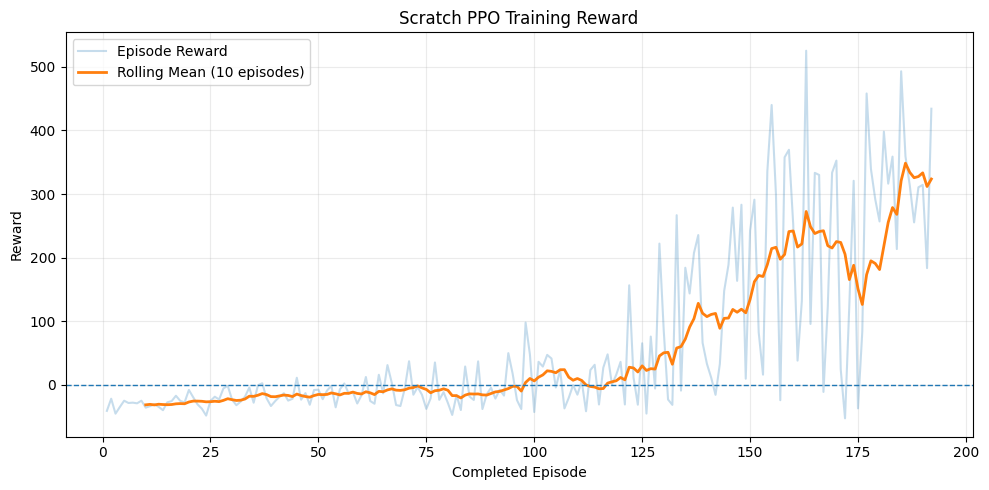

Saved: /content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2/results/scratch_training_curve.png


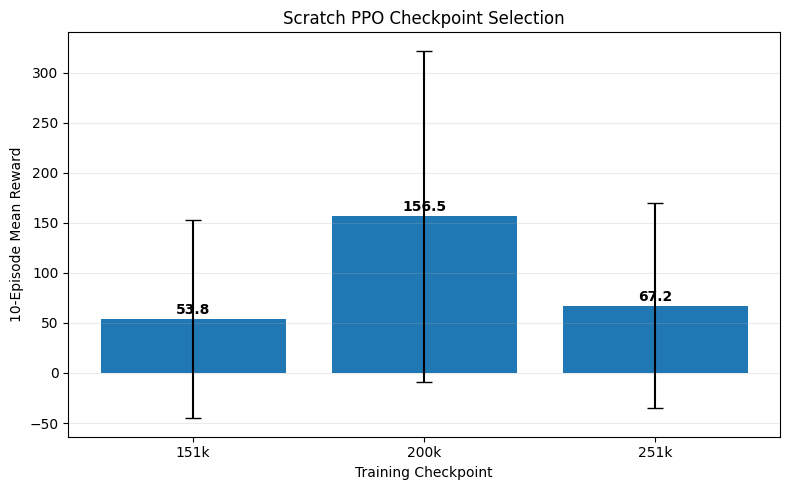

Saved: /content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2/results/scratch_checkpoint_comparison.png


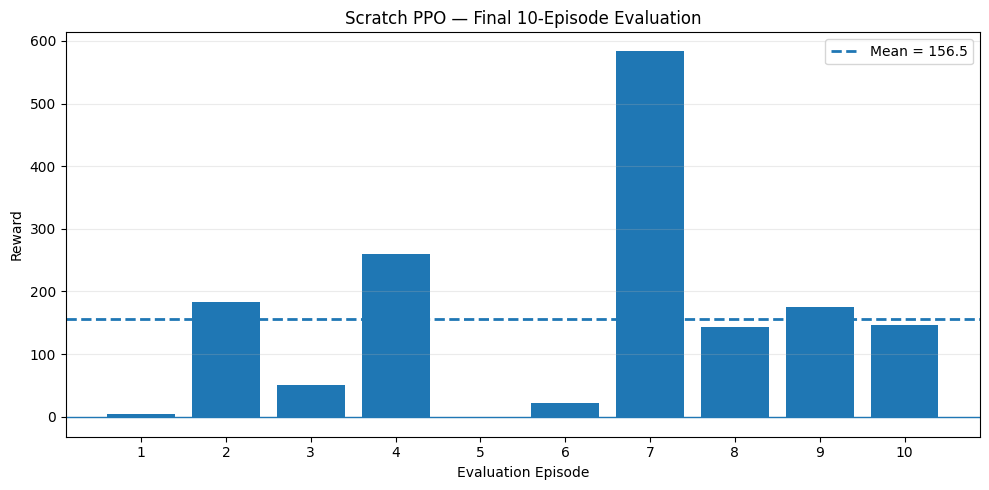

Saved: /content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2/results/scratch_final_evaluation.png

FINAL SCRATCH PPO SUMMARY
---------------------------------------------
Checkpoint : repo_port_200704.pt
Mean       : 156.5
Std        : 165.3
Best       : 584.4
Worst      : -2.7
Training episodes stored: 192

Plots saved in:
/content/drive/MyDrive/CarRacing_PPO_Repo_Port_Run2/results


In [13]:
# ============================================================
# FINAL SCRATCH PPO — RESULTS & PLOTS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import torch

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(RESULTS_DIR, exist_ok=True)


# ============================================================
# 1. FINAL EVALUATION DATA
# ============================================================

scratch_eval_scores = np.array([
    3.7,
    183.8,
    50.5,
    259.7,
    -2.7,
    21.4,
    584.4,
    143.4,
    174.4,
    145.9
])

scratch_mean = scratch_eval_scores.mean()
scratch_std = scratch_eval_scores.std()
scratch_best = scratch_eval_scores.max()
scratch_worst = scratch_eval_scores.min()


print("=" * 60)
print("FINAL SCRATCH PPO RESULTS")
print("=" * 60)

print(f"Selected checkpoint : 200,704 steps")
print(f"Evaluation episodes : {len(scratch_eval_scores)}")
print(f"Mean reward         : {scratch_mean:.1f}")
print(f"Standard deviation  : {scratch_std:.1f}")
print(f"Best episode        : {scratch_best:.1f}")
print(f"Worst episode       : {scratch_worst:.1f}")

print("=" * 60)


# ============================================================
# 2. TRAINING REWARD CURVE
# Load rewards stored inside selected checkpoint
# ============================================================

BEST_SCRATCH_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "repo_port_200704.pt"
)

checkpoint = torch.load(
    BEST_SCRATCH_CHECKPOINT,
    map_location="cpu"
)

training_rewards = np.array(
    checkpoint["episode_rewards"],
    dtype=np.float32
)

# Each batch contains 16 parallel environments.
# Plot raw episode rewards plus rolling mean.
window = 10

rolling_mean = np.convolve(
    training_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(10, 5))

plt.plot(
    np.arange(1, len(training_rewards) + 1),
    training_rewards,
    alpha=0.25,
    label="Episode Reward"
)

plt.plot(
    np.arange(window, len(training_rewards) + 1),
    rolling_mean,
    linewidth=2,
    label="Rolling Mean (10 episodes)"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Completed Episode")
plt.ylabel("Reward")
plt.title("Scratch PPO Training Reward")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

training_plot_path = os.path.join(
    RESULTS_DIR,
    "scratch_training_curve.png"
)

plt.savefig(
    training_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", training_plot_path)


# ============================================================
# 3. CHECKPOINT SELECTION
# ============================================================

checkpoint_names = [
    "151k",
    "200k",
    "251k"
]

checkpoint_means = np.array([
    53.8,
    156.5,
    67.2
])

checkpoint_stds = np.array([
    99.1,
    165.3,
    102.2
])

plt.figure(figsize=(8, 5))

bars = plt.bar(
    checkpoint_names,
    checkpoint_means,
    yerr=checkpoint_stds,
    capsize=6
)

plt.xlabel("Training Checkpoint")
plt.ylabel("10-Episode Mean Reward")
plt.title("Scratch PPO Checkpoint Selection")
plt.grid(
    axis="y",
    alpha=0.25
)

for bar, value in zip(
    bars,
    checkpoint_means
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f"{value:.1f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

checkpoint_plot_path = os.path.join(
    RESULTS_DIR,
    "scratch_checkpoint_comparison.png"
)

plt.savefig(
    checkpoint_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", checkpoint_plot_path)


# ============================================================
# 4. FINAL 10-EPISODE EVALUATION
# ============================================================

episodes = np.arange(
    1,
    len(scratch_eval_scores) + 1
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    episodes,
    scratch_eval_scores
)

plt.axhline(
    scratch_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {scratch_mean:.1f}"
)

plt.axhline(
    0,
    linewidth=1
)

plt.xticks(episodes)

plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")
plt.title(
    "Scratch PPO — Final 10-Episode Evaluation"
)

plt.legend()
plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

evaluation_plot_path = os.path.join(
    RESULTS_DIR,
    "scratch_final_evaluation.png"
)

plt.savefig(
    evaluation_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", evaluation_plot_path)


# ============================================================
# 5. SUMMARY
# ============================================================

print("\nFINAL SCRATCH PPO SUMMARY")
print("-" * 45)

print(
    f"Checkpoint : repo_port_200704.pt"
)

print(
    f"Mean       : {scratch_mean:.1f}"
)

print(
    f"Std        : {scratch_std:.1f}"
)

print(
    f"Best       : {scratch_best:.1f}"
)

print(
    f"Worst      : {scratch_worst:.1f}"
)

print(
    f"Training episodes stored: "
    f"{len(training_rewards)}"
)

print("\nPlots saved in:")
print(RESULTS_DIR)

## 10. Final Observations

The selected **200,704-step** Scratch PPO checkpoint achieved **156.5 ± 165.3** mean reward across 10 fixed evaluation tracks, with a best episode of **584.4** and a worst episode of **-2.7**.

Training performance was non-monotonic: later checkpoints did not necessarily generalize better. Evaluating multiple checkpoints was therefore important for model selection. Qualitatively, the selected policy learned useful cornering and recovery behavior, while remaining inconsistent on some sharper turns.
